# ASSISTments + IRT 探索性分析

本 Notebook 展示数据清洗后的学生交互、因果历史特征、Rasch 学生能力与题目难度，以及模型结果。正式训练逻辑位于 `src/`，避免把全部代码放在 Notebook 中。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path('..')
data = pd.read_csv(project_root / 'data/processed/features.csv')
results = pd.read_csv(project_root / 'artifacts/results.csv')
data.head()

,user_id,problem_id,correct,order_id,skill_id,split,student_attempts_before,student_correct_before,student_historical_accuracy,recent_accuracy_5,skill_attempts_before,skill_correct_before,skill_historical_accuracy,theta,item_difficulty,theta_minus_difficulty,irt_probability
0,14,93383,0,21617623,2_37_70,train,0,0,0.500000,0.500000,0,0,0.500000,-0.510446,0.631133,-1.141579,0.242031
1,14,93407,1,21617632,2_37_70,train,1,0,0.000000,0.000000,1,0,0.000000,-0.510446,0.371566,-0.882013,0.292761
2,14,93400,0,21617641,2_37_70,train,2,1,0.500000,0.500000,2,1,0.500000,-0.510446,0.795082,-1.305528,0.213236
3,14,93419,0,21617650,2_37_70,train,3,1,0.333333,0.333333,3,1,0.333333,-0.510446,0.979219,-1.489665,0.183972
4,14,93420,0,21617659,2_37_70,train,4,1,0.250000,0.250000,4,1,0.250000,-0.510446,1.102792,-1.613238,0.166140


## 数据概况

数据按学生内 `order_id` 排序。历史正确率和最近正确率只读取当前交互之前的答案；当前 `correct` 只作为预测目标。

In [2]:
print(f'交互数: {len(data):,}')
print(f'学生数: {data.user_id.nunique():,}')
print(f'题目数: {data.problem_id.nunique():,}')
print(data['split'].value_counts())
data.groupby('user_id').size().describe()

交互数: 341,879
学生数: 3,168
题目数: 26,628
split
train         237936
test           54183
validation     49760
Name: count, dtype: int64


count    3168.000000
mean      107.916351
std       181.698184
min        10.000000
25%        18.000000
50%        38.000000
75%       105.000000
max      1383.000000
dtype: float64

## 结果表

主要比较 Test 集上的 AUC、LogLoss 和 Brier Score。LogLoss 与 Brier Score 越低越好，AUC 越高越好。

In [3]:
results[results['split'] == 'test'].sort_values('auc')

,model,split,auc,logloss,brier_score,accuracy,f1
1,Logistic Regression,test,0.714467,0.585322,0.199532,0.698411,0.791369
5,XGBoost,test,0.718092,0.577984,0.196645,0.703855,0.793801
3,Rasch IRT,test,0.745363,0.567998,0.192828,0.706070,0.782758
7,XGBoost + IRT,test,0.766658,0.566566,0.189294,0.718989,0.783315


## 已生成图表

训练命令会把中文图表写入 `artifacts/figures/`，包括交互次数、正确率、学生能力、题目难度、模型比较和特征重要性。

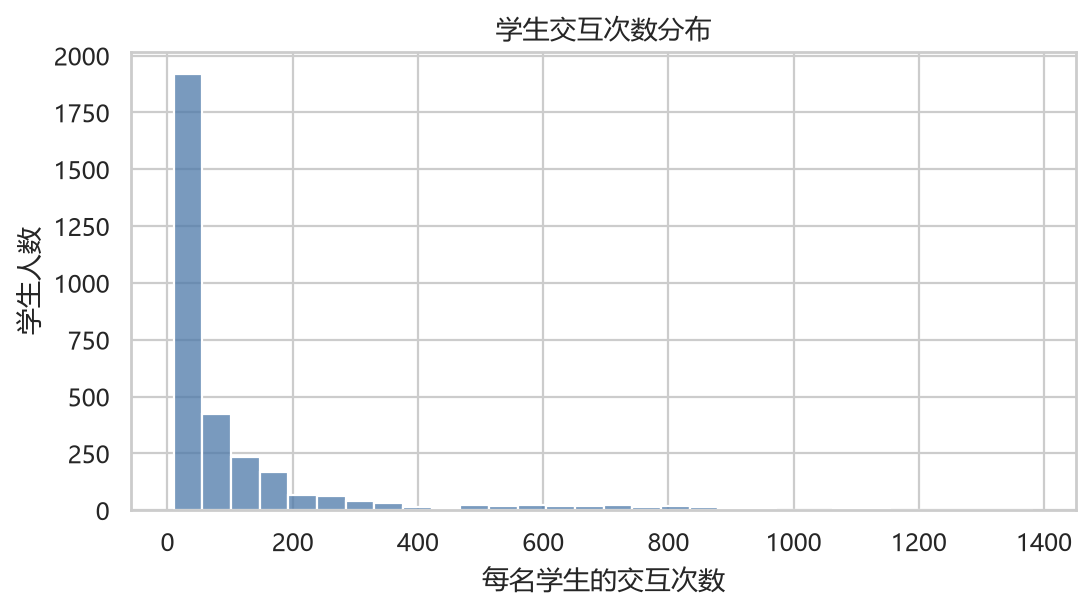

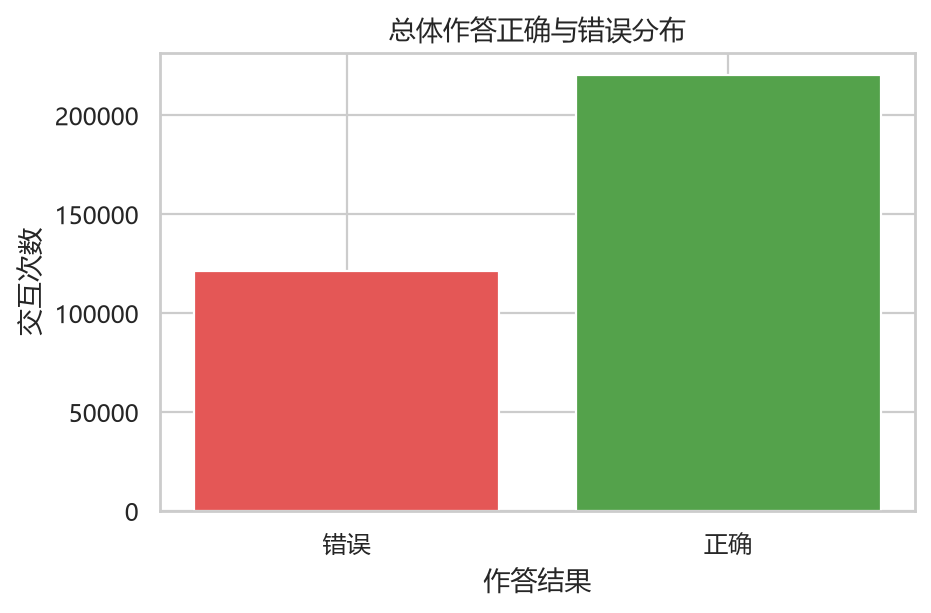

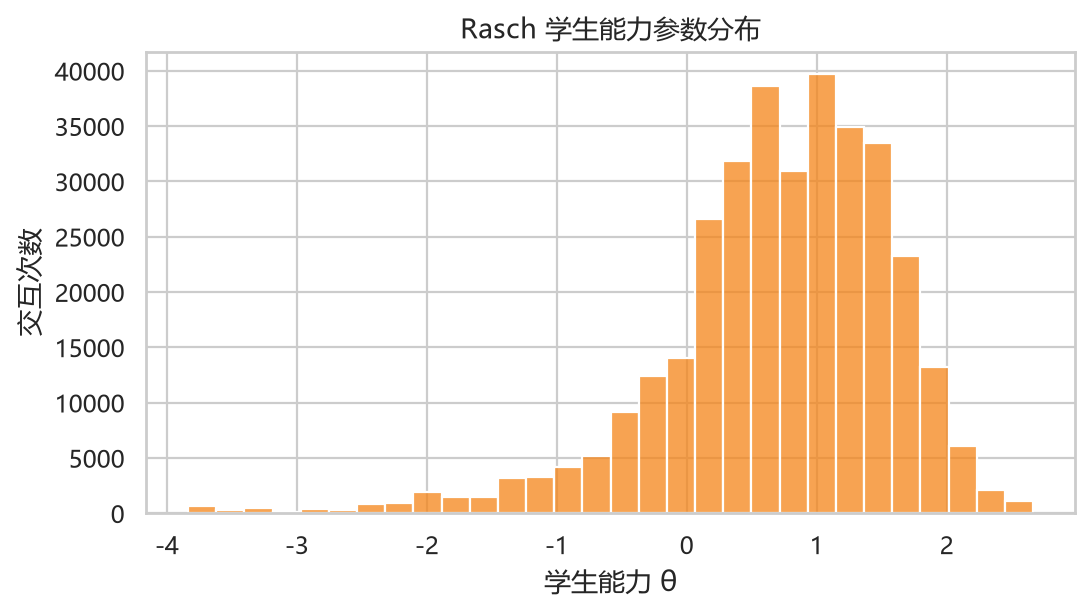

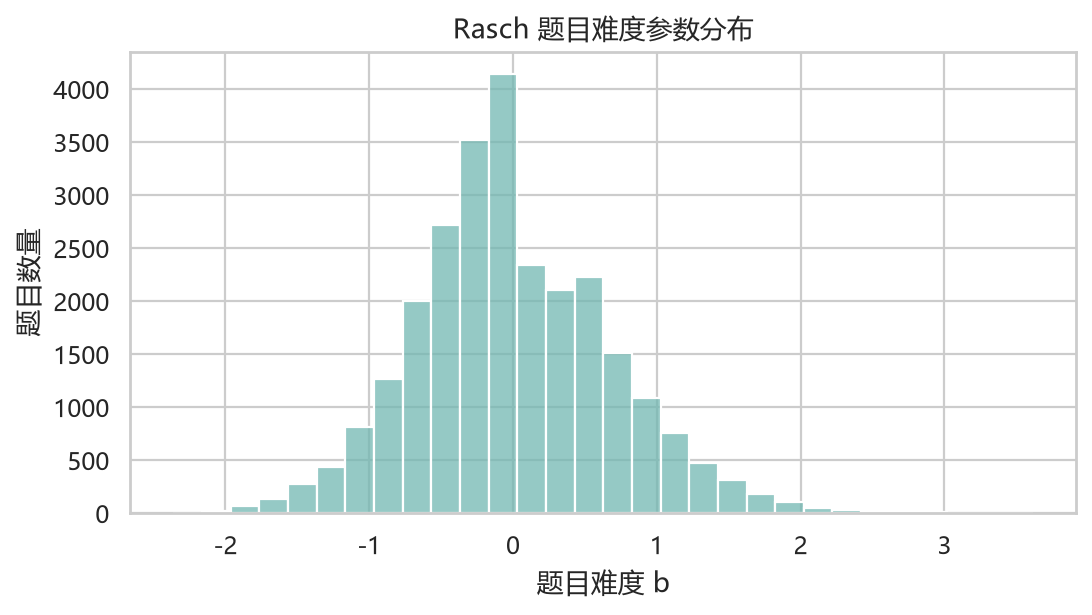

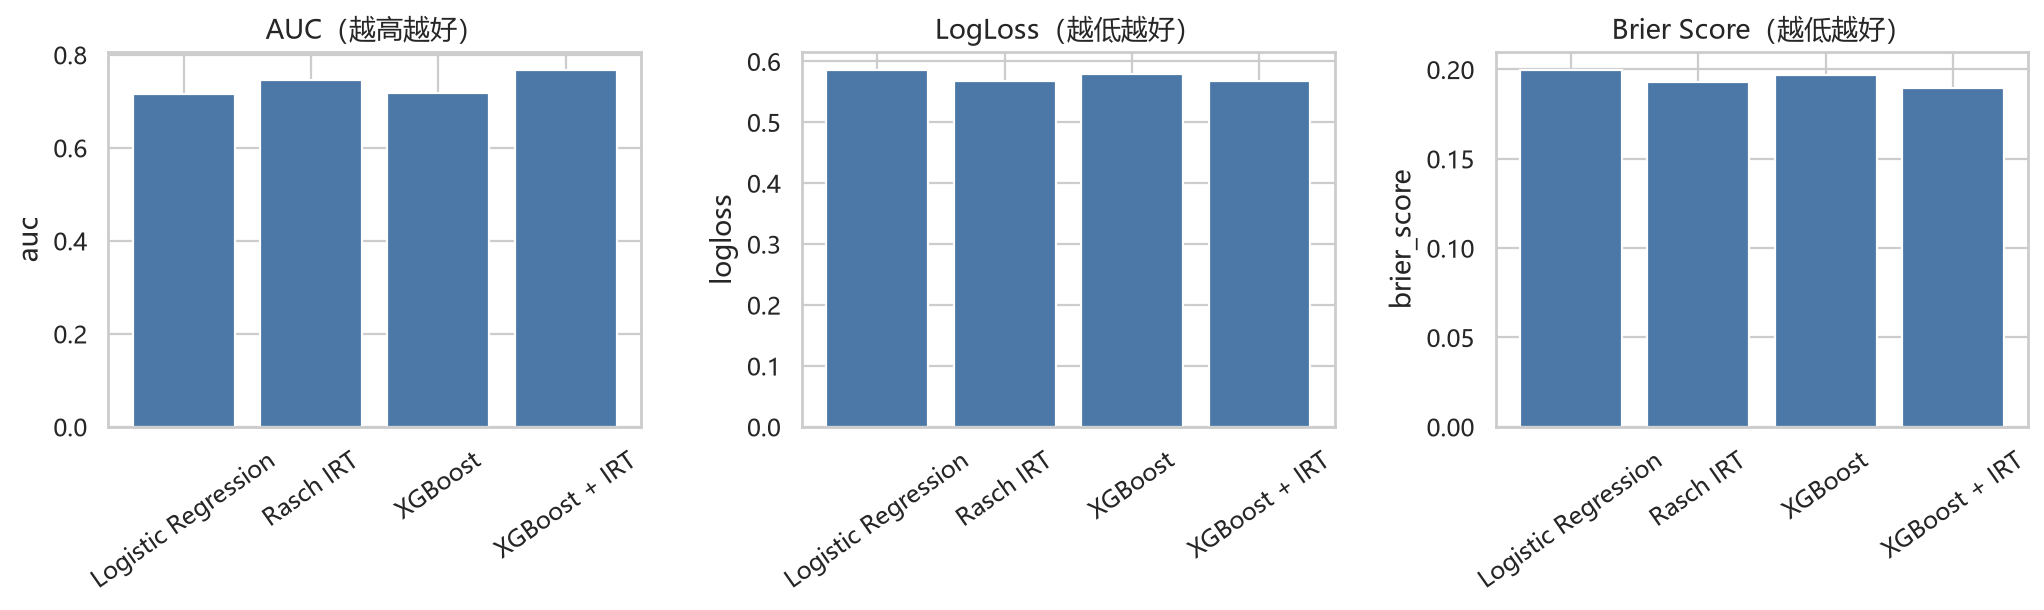

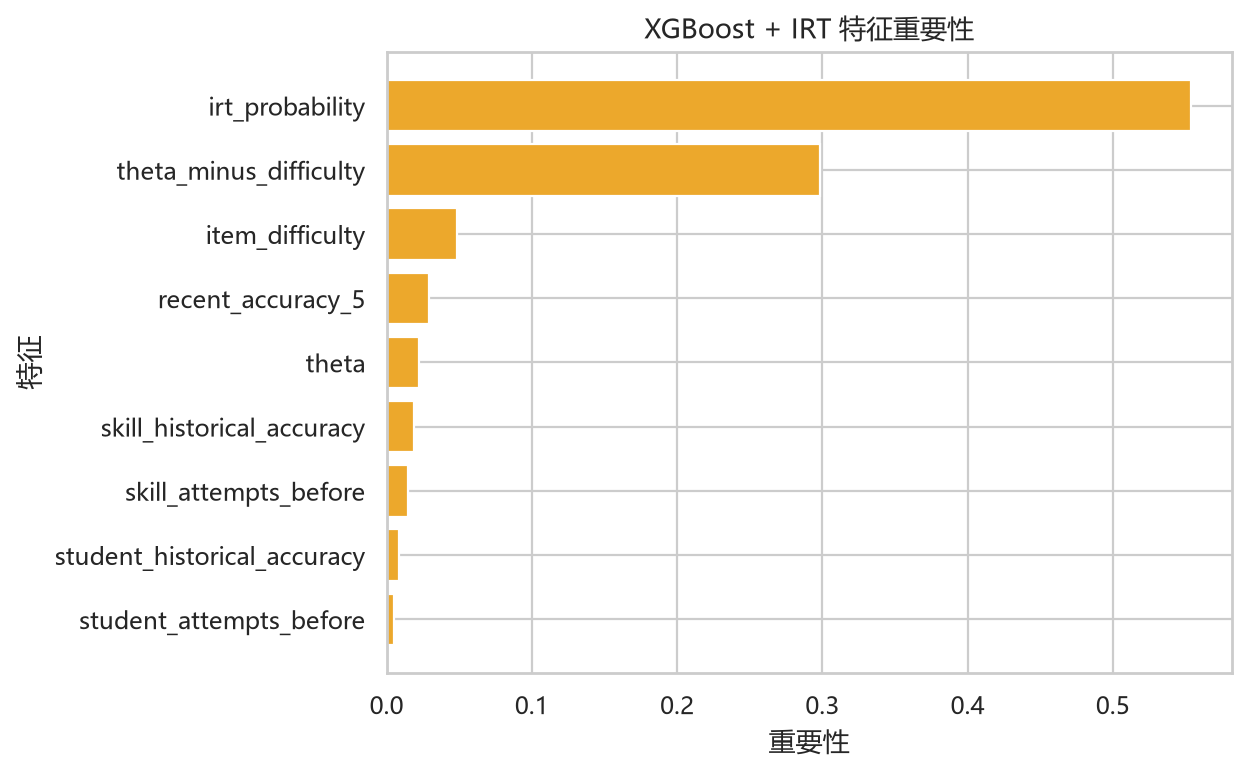

In [4]:
from IPython.display import Image, display
for name in ['interaction_count_distribution.png', 'correctness_distribution.png', 'theta_distribution.png', 'item_difficulty_distribution.png', 'model_comparison.png', 'feature_importance.png']:
    path = project_root / 'artifacts/figures' / name
    if path.exists():
        display(Image(filename=str(path)))